# Numerical Simulation Laboratory - Notebook 2

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import math

## Exercise 02.1

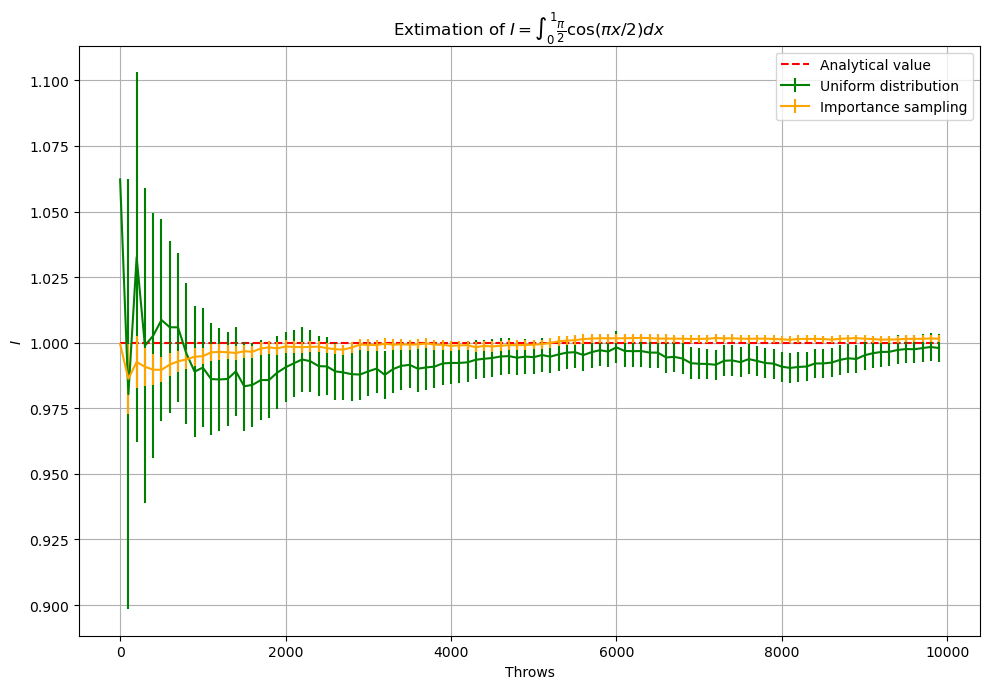

In [ ]:
x_uniform, I_uniform, err_uniform = np.loadtxt("../02-Exercises/OUTPUT/uniform.out", unpack=True)
x_importance, I_importance, err_importance = np.loadtxt("OUTPUT/importance.out", unpack=True)

fig, ax = plt.subplots(figsize=(10,7))

ax.plot(x_uniform, [1.]*x_uniform.size, "r--", label="Analytical value")
ax.errorbar(x_uniform, I_uniform, yerr=err_uniform, color="g", label="Uniform distribution");
ax.errorbar(x_importance, I_importance, yerr=err_importance, color="orange", label="Importance sampling");

ax.set_title(r"Extimation of $I = \int_0^1 \frac{\pi}{2}\cos(\pi x/2) dx$")
ax.set_xlabel("Throws")
ax.set_ylabel("$I$")

fig.tight_layout()
ax.legend()
ax.grid();

To integrate with importance sampling I've used the first order Taylor expansion of $\cos\left(\frac{\pi}{2}x\right)$ in $x=1$:
$$ \cos\left(\frac{\pi}{2}x\right) = -\frac{\pi}{2}(x-1) \text{.}$$
This expansion can be used as the probability distribution for the importance sampling after normalization
$$\int_0^1\frac{\pi}{2}(1-x)dx=\frac{\pi}{4}\text{,}$$
$$p(x)=2(1-x)\text{,}$$
$$\int_0^1\cos\left(\frac{\pi}{2}x\right)dx=\int_0^1\frac{\pi\cos\left(\frac{\pi}{2}x\right)}{4(1-x)}2(1-x)dx\text{.}$$
The probability distribution $p(x)$ can be sampled from a uniform distribution by inverting the cumulative funtion
$$y=\int_0^x2(1-x^\prime)dx^\prime=2x-x^2\implies x=1-\sqrt{1-y}\text{,}$$
with $y\in\mathcal{U}[0,1]$.
The figure shows that the integral with importance sampling converges faster and has lower error than the one with uniform sampling. Both methods converge to the true value of $I$.

## Excercise 02.2

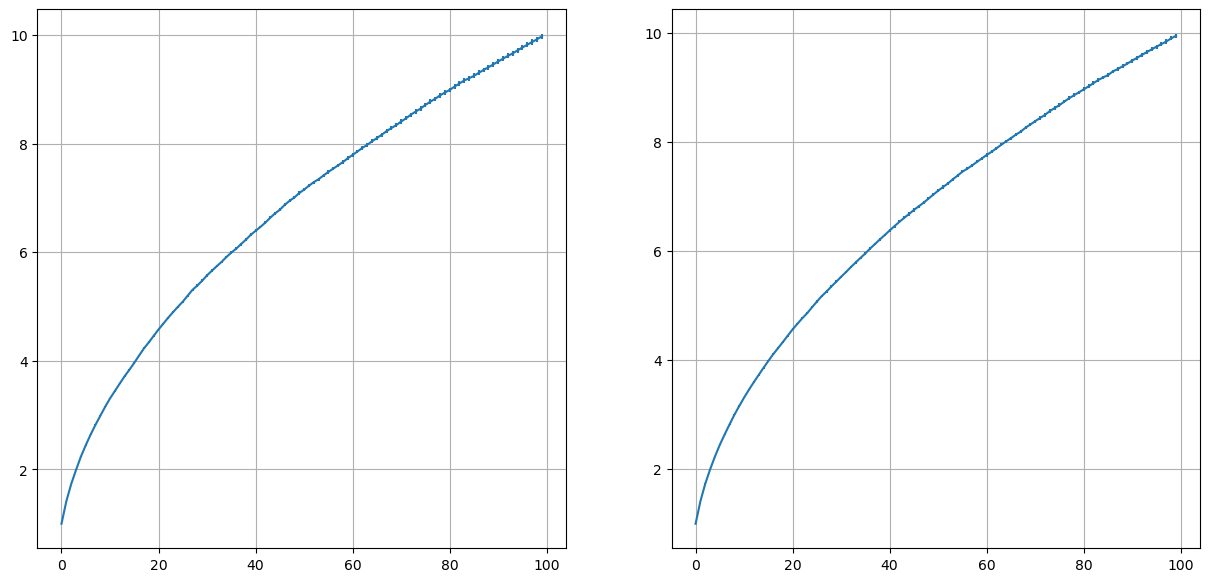

In [7]:
x_lattice, dist_lattice, err_lattice = np.loadtxt("02.2/RW_lattice.out", unpack=True)
x_cont, dist_cont, err_cont = np.loadtxt("02.2/RW_continuum.out", unpack=True)

fig, axs = plt.subplots(1, 2, figsize=(15,7))

axs[0].errorbar(x_lattice, dist_lattice, yerr=err_lattice);
axs[1].errorbar(x_cont, dist_cont, yerr=err_cont);

for ax in axs:
    ax.grid();